# NB07 — Markov-Kernel Depth Sweep

Reruns the NB06 next-state-prediction setup at four hierarchy depths:

| depth | K leaves | leaf granularity |
|---|---|---|
| 1 | 2 | half-plane split on the higher-variance axis |
| 2 | 4 | NB06 setting — quadrants |
| 3 | 8 | finer cells |
| 4 | 16 | NB04 original — fine grid |

Everything else is identical to NB06: same 3 tickers, horizon=5 days, val-tuned RF on a 3×3 grid, same 6 models (random / marginal / persistence / empirical Markov / RF features-only / RF joint).

The question: is "RF beats persistence by ~10 pp" robust to hierarchy depth, or was K=4 a sweet spot?

Cost guard: yfinance downloads are cached per ticker.


In [1]:
import math, os, json, random
from dataclasses import dataclass
from datetime import datetime
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
random.seed(SEED); np.random.seed(SEED)

TICKERS = ["SPY", "NVDA", "BTC-USD"]
DEPTHS = [1, 2, 3, 4]
START_DATE = "2010-01-01"
END_DATE = None
HORIZON = 5
TEST_FRACTION = 0.20
VALIDATION_FRACTION = 0.15
MIN_LEAF_COUNT = 200
RF_N_ESTIMATORS = 300
RF_GRID = [{"max_depth": md_, "min_samples_leaf": msl}
           for md_ in (4, 6, 8) for msl in (10, 20, 40)]
JOURNAL_PATH = "EXPERIMENTS.md"


## Reused helpers (same as NB06)

Data loading, features, hierarchy, state assignment, RF fit-with-val-tuning. Yfinance pulls are cached in `_YF_CACHE` so each ticker is downloaded once.


In [2]:
_YF_CACHE: Dict[str, pd.DataFrame] = {}

def load_yfinance_ohlcv(ticker, start_date, end_date=None):
    key = (ticker, start_date, end_date)
    if key in _YF_CACHE:
        return _YF_CACHE[key].copy()
    raw = yf.download(tickers=ticker, start=start_date, end=end_date,
                     auto_adjust=True, progress=False, group_by="column")
    if raw.empty:
        raise RuntimeError(f"No data returned for ticker: {ticker}")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = [c[0].lower() for c in raw.columns]
    else:
        raw.columns = [str(c).lower() for c in raw.columns]
    df = raw[["open","high","low","close","volume"]].copy().reset_index()
    df = df.rename(columns={"Date":"date","Datetime":"date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.dropna().reset_index(drop=True)
    _YF_CACHE[key] = df
    return df.copy()


def rolling_zscore(x, w, eps=1e-8):
    m = x.rolling(w, min_periods=max(3, w // 3)).mean()
    s = x.rolling(w, min_periods=max(3, w // 3)).std()
    return (x - m) / (s + eps)


def sigmoid_np(x): return 1.0 / (1.0 + np.exp(-x))


def make_real_market_features(df, horizon):
    out = df.copy()
    for lag in (1, 2, 5, 10, 20):
        out[f"ret_{lag}"] = out["close"].pct_change(lag)
    out["range_pct"] = (out["high"] - out["low"]) / out["close"]
    out["open_close_pct"] = (out["close"] - out["open"]) / out["open"]
    for w in (5, 10, 20):
        out[f"vol_{w}"] = out["ret_1"].rolling(w).std()
    for w in (10, 20, 50):
        out[f"ma_{w}"] = out["close"].rolling(w).mean()
        out[f"price_to_ma_{w}"] = out["close"] / out[f"ma_{w}"] - 1.0
    out["volume_log"] = np.log1p(out["volume"])
    out["volume_z_20"] = rolling_zscore(out["volume_log"], 20)
    for w in (20, 50):
        out[f"rolling_max_{w}"] = out["close"].rolling(w).max()
        out[f"drawdown_{w}"] = out["close"] / out[f"rolling_max_{w}"] - 1.0
    out["trend_pressure"] = rolling_zscore(out["ret_10"], 30)
    out["fear_pressure"] = (-4.0*out["drawdown_20"] - 2.0*out["drawdown_50"]
                            + 8.0*out["vol_10"] + 0.35*out["volume_z_20"]
                            - 0.50*out["ret_5"])
    out["greed_pressure"] = (1.50*out["trend_pressure"] + 2.00*out["price_to_ma_20"]
                              + 1.00*out["ret_20"] + 0.20*out["volume_z_20"]
                              - 3.00*out["vol_20"])
    out["fear_index"] = sigmoid_np(out["fear_pressure"].clip(-8, 8))
    out["greed_index"] = sigmoid_np(out["greed_pressure"].clip(-8, 8))
    out["future_close"] = out["close"].shift(-horizon)
    out["future_return"] = out["future_close"] / out["close"] - 1.0
    out["future_direction"] = (out["future_return"] > 0).astype(int)
    return out.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)


BASELINE_FEATURES = [
    "ret_1","ret_2","ret_5","ret_10","ret_20",
    "range_pct","open_close_pct",
    "vol_5","vol_10","vol_20",
    "price_to_ma_10","price_to_ma_20","price_to_ma_50",
    "volume_z_20","drawdown_20","drawdown_50",
]


@dataclass
class MeasureNode:
    node_id: str
    depth: int
    bounds: Dict[str, Tuple[float, float]]
    mass: float
    count: int
    mean: Dict[str, float]
    children: Optional[List["MeasureNode"]] = None
    @property
    def is_leaf(self): return not self.children


def in_bounds(row, bounds):
    for col, (lo, hi) in bounds.items():
        v = float(row[col])
        if not (lo <= v < hi): return False
    return True


def split_node(node, split_col, split_value):
    lo, hi = node.bounds[split_col]
    lb, rb = dict(node.bounds), dict(node.bounds)
    lb[split_col] = (lo, split_value); rb[split_col] = (split_value, hi)
    node.children = [
        MeasureNode(node.node_id+"L", node.depth+1, lb, node.mass/2, 0, {}, None),
        MeasureNode(node.node_id+"R", node.depth+1, rb, node.mass/2, 0, {}, None),
    ]
    return node.children


def collect_leaves(node):
    if node.is_leaf: return [node]
    return [l for c in node.children for l in collect_leaves(c)]


def build_hierarchy(train_df, max_depth, min_count=200):
    feat = ["greed_index", "fear_index"]
    root = MeasureNode("root", 0,
                       {"greed_index":(0.0, 1.000001), "fear_index":(0.0, 1.000001)},
                       1.0, len(train_df),
                       {c: float(train_df[c].mean()) for c in feat}, None)
    queue = [root]
    while queue:
        n = queue.pop(0)
        if n.depth >= max_depth: continue
        mask = train_df.apply(lambda r: in_bounds(r, n.bounds), axis=1)
        sub = train_df[mask]
        n.count = len(sub); n.mass = n.count / max(len(train_df), 1)
        if n.count < min_count: continue
        v = {c: float(sub[c].var()) for c in feat}
        sc = max(v, key=v.get); sv = float(sub[sc].median())
        if n.bounds[sc][0] < sv < n.bounds[sc][1]:
            queue.extend(split_node(n, sc, sv))
    for leaf in collect_leaves(root):
        mask = train_df.apply(lambda r: in_bounds(r, leaf.bounds), axis=1)
        sub = train_df[mask]
        leaf.count = len(sub); leaf.mass = leaf.count / max(len(train_df), 1)
        leaf.mean = {c: (float(sub[c].mean()) if len(sub) else 0.0) for c in feat}
    return root


def soft_membership(row, leaves, temperature=0.04):
    p = np.array([float(row["greed_index"]), float(row["fear_index"])])
    centers = np.array([[(l.bounds["greed_index"][0]+l.bounds["greed_index"][1])/2,
                          (l.bounds["fear_index"][0]+l.bounds["fear_index"][1])/2]
                         for l in leaves])
    d = np.sum((centers - p[None,:])**2, axis=1)
    logits = -d / max(temperature, 1e-8); logits -= logits.max()
    w = np.exp(logits); return w / w.sum()


def add_memberships(frame, leaves, cols):
    M = np.vstack([soft_membership(r, leaves) for _, r in frame.iterrows()])
    return pd.concat([frame.reset_index(drop=True),
                      pd.DataFrame(M, columns=cols).reset_index(drop=True)], axis=1)


def time_split(frame, vf, tf):
    n = len(frame); ts = int(n * (1 - tf)); vs = int(ts * (1 - vf))
    return frame.iloc[:vs].copy(), frame.iloc[vs:ts].copy(), frame.iloc[ts:].copy()


def assign_leaf_index(row, leaves):
    for i, leaf in enumerate(leaves):
        if in_bounds(row, leaf.bounds): return i
    return -1


def add_states(frame, leaves, horizon):
    frame = frame.copy()
    frame["state_t"] = frame.apply(lambda r: assign_leaf_index(r, leaves), axis=1)
    frame["state_t_future"] = frame["state_t"].shift(-horizon)
    return frame.dropna(subset=["state_t_future"]).reset_index(drop=True).astype({"state_t":int, "state_t_future":int})


def _rf_cls(params):
    return RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, random_state=SEED, n_jobs=-1,
                                   class_weight="balanced_subsample", **params)


def select_rf_cls_params(x_train, y_train, x_val, y_val):
    best, bs = None, -np.inf
    for p in RF_GRID:
        m = _rf_cls(p); m.fit(x_train, y_train)
        s = f1_score(y_val, m.predict(x_val), average="macro")
        if s > bs: best, bs = p, s
    return best, bs


def fit_rf_classifier(feature_columns, tr, va, te):
    xt, yv_t = tr[feature_columns], tr["state_t_future"].astype(int)
    xv, yv_v = va[feature_columns], va["state_t_future"].astype(int)
    xe, yv_e = te[feature_columns], te["state_t_future"].astype(int)
    best, val_f1 = select_rf_cls_params(xt, yv_t, xv, yv_v)
    xtrv = pd.concat([xt, xv]); ytrv = pd.concat([yv_t, yv_v])
    m = _rf_cls(best); m.fit(xtrv, ytrv)
    return m.predict(xe), m, best, float(val_f1)


def estimate_transition_matrix(s, u, K):
    M = np.zeros((K, K))
    for a, b in zip(s, u): M[int(a), int(b)] += 1
    rs = M.sum(axis=1, keepdims=True)
    return M / np.maximum(rs, 1.0)


def empirical_markov_predict(state_t, T):
    table = T.argmax(axis=1)
    return np.array([table[int(s)] for s in state_t])


def score_predictions(y_true, y_pred, state_t):
    tm = (y_true != state_t)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "transition_count": int(tm.sum()),
        "transition_accuracy": float(accuracy_score(y_true[tm], y_pred[tm])) if tm.any() else float("nan"),
    }


## Run the (ticker × depth) grid


In [3]:
def run_single(ticker, depth, rng):
    df = load_yfinance_ohlcv(ticker, START_DATE, END_DATE)
    feat = make_real_market_features(df, HORIZON)
    train_df, val_df, test_df = time_split(feat, VALIDATION_FRACTION, TEST_FRACTION)

    root = build_hierarchy(train_df, max_depth=depth, min_count=MIN_LEAF_COUNT)
    leaves = collect_leaves(root); K = len(leaves)
    cols = [f"leaf_{l.node_id}" for l in leaves]

    tr_s = add_states(train_df, leaves, HORIZON)
    va_s = add_states(val_df, leaves, HORIZON)
    te_s = add_states(test_df, leaves, HORIZON)
    tr_m = add_memberships(tr_s, leaves, cols)
    va_m = add_memberships(va_s, leaves, cols)
    te_m = add_memberships(te_s, leaves, cols)

    y = te_m["state_t_future"].astype(int).to_numpy()
    z = te_m["state_t"].astype(int).to_numpy()

    pr_rand = rng.integers(0, K, size=len(te_m))
    majority = int(pd.Series(tr_m["state_t_future"].astype(int)).value_counts().idxmax())
    pr_marg = np.full(len(te_m), majority, dtype=int)
    pr_pers = z.copy()
    T = estimate_transition_matrix(tr_m["state_t"].astype(int).to_numpy(),
                                   tr_m["state_t_future"].astype(int).to_numpy(), K)
    pr_mkv = empirical_markov_predict(z, T)
    pr_feat, m_feat, p_feat, vf_feat = fit_rf_classifier(BASELINE_FEATURES, tr_m, va_m, te_m)
    pr_joint, m_joint, p_joint, vf_joint = fit_rf_classifier(BASELINE_FEATURES + cols, tr_m, va_m, te_m)

    rows = []
    for name, pr in [("random", pr_rand), ("marginal", pr_marg), ("persistence", pr_pers),
                      ("empirical_markov", pr_mkv), ("rf_features_only", pr_feat), ("rf_joint", pr_joint)]:
        s = score_predictions(y, pr, z)
        s.update({"ticker": ticker, "depth": depth, "K": K, "model": name,
                  "n_train": len(tr_m), "n_val": len(va_m), "n_test": len(te_m)})
        rows.append(s)
    return pd.DataFrame(rows), {"rf_feat_params": p_feat, "rf_joint_params": p_joint,
                                 "val_f1_feat": vf_feat, "val_f1_joint": vf_joint,
                                 "transition_matrix": T}


rng = np.random.default_rng(SEED)
all_rows = []
all_info = {}
for tk in TICKERS:
    for d in DEPTHS:
        print(f"Running {tk} depth={d}...")
        df_one, info = run_single(tk, d, rng)
        all_rows.append(df_one)
        all_info[(tk, d)] = info

agg = pd.concat(all_rows, ignore_index=True)
agg[["ticker", "depth", "K", "model", "n_train", "n_val", "n_test",
     "accuracy", "macro_f1", "transition_count", "transition_accuracy"]]


Running SPY depth=1...


Running SPY depth=2...


Running SPY depth=3...


Running SPY depth=4...


Running NVDA depth=1...


...

Running BTC-USD depth=1...


Running BTC-USD depth=2...


Running BTC-USD depth=3...


Running BTC-USD depth=4...


,ticker,depth,K,model,n_train,n_val,n_test,accuracy,macro_f1,transition_count,transition_accuracy
0,SPY,1,2,random,2754,483,807,0.490706,0.490706,315,0.536508
1,SPY,1,2,marginal,2754,483,807,0.509294,0.337438,315,0.501587
2,SPY,1,2,persistence,2754,483,807,0.609665,0.609548,315,0.000000
3,SPY,1,2,empirical_markov,2754,483,807,0.609665,0.609548,315,0.000000
4,SPY,1,2,rf_features_only,2754,483,807,0.759603,0.758854,315,0.584127
...,...,...,...,...,...,...,...,...,...,...,...
67,BTC-USD,4,16,marginal,2851,500,836,0.021531,0.002635,719,0.019471
68,BTC-USD,4,16,persistence,2851,500,836,0.139952,0.136422,719,0.000000
69,BTC-USD,4,16,empirical_markov,2851,500,836,0.131579,0.090422,719,0.068150
70,BTC-USD,4,16,rf_features_only,2851,500,836,0.188995,0.162659,719,0.169680


## Summary — accuracy and gap-over-persistence per (ticker, depth)


In [4]:
def gap_table(agg, value_col):
    base = agg[agg["model"] == "persistence"].set_index(["ticker", "depth"])[value_col]
    others = agg.set_index(["ticker", "depth", "model"])[value_col].unstack("model")
    gap = others.sub(base, axis=0)
    return others, gap

acc_table, acc_gap = gap_table(agg, "accuracy")
print("Test accuracy:")
print(acc_table.round(4))
print()
print("Accuracy gap vs persistence (positive = beats persistence):")
print(acc_gap.round(4))


Test accuracy:
model          empirical_markov  marginal  persistence  random  \
ticker  depth                                                    
BTC-USD 1                0.6699    0.5203       0.6699  0.4797   
        2                0.4211    0.2309       0.4211  0.2560   
        3                0.2572    0.0670       0.2608  0.1292   
        4                0.1316    0.0215       0.1400  0.0610   
NVDA    1                0.6431    0.5254       0.6431  0.4857   
        2                0.3916    0.2763       0.3916  0.2416   
        3                0.2144    0.1314       0.1958  0.1276   
        4                0.1029    0.0731       0.0979  0.0694   
SPY     1                0.6097    0.5093       0.6097  0.4907   
        2                0.3606    0.2528       0.3532  0.2342   
        3                0.2032    0.1202       0.2020  0.1264   
        4                0.1140    0.0533       0.1078  0.0458   

model          rf_features_only  rf_joint  
ticker  depth   

In [5]:
tx_table, tx_gap = gap_table(agg, "transition_accuracy")
print("Test transition accuracy (model accuracy on rows where state actually changed):")
print(tx_table.round(4))


Test transition accuracy (model accuracy on rows where state actually changed):
model          empirical_markov  marginal  persistence  random  \
ticker  depth                                                    
BTC-USD 1                0.0000    0.5000          0.0  0.5109   
        2                0.0000    0.2231          0.0  0.2521   
        3                0.0663    0.0680          0.0  0.1197   
        4                0.0682    0.0195          0.0  0.0626   
NVDA    1                0.0000    0.5035          0.0  0.5035   
        2                0.0000    0.2505          0.0  0.2546   
        3                0.0940    0.1371          0.0  0.1341   
        4                0.0824    0.0728          0.0  0.0646   
SPY     1                0.0000    0.5016          0.0  0.5365   
        2                0.2146    0.2816          0.0  0.2280   
        3                0.1196    0.1335          0.0  0.1289   
        4                0.0819    0.0556          0.0  0.0403

## Plots — accuracy and persistence vs RF as a function of depth

One panel per ticker. We plot persistence, empirical_markov, rf_features_only, and rf_joint. The "chance" line is `1/K` and is a function of depth.


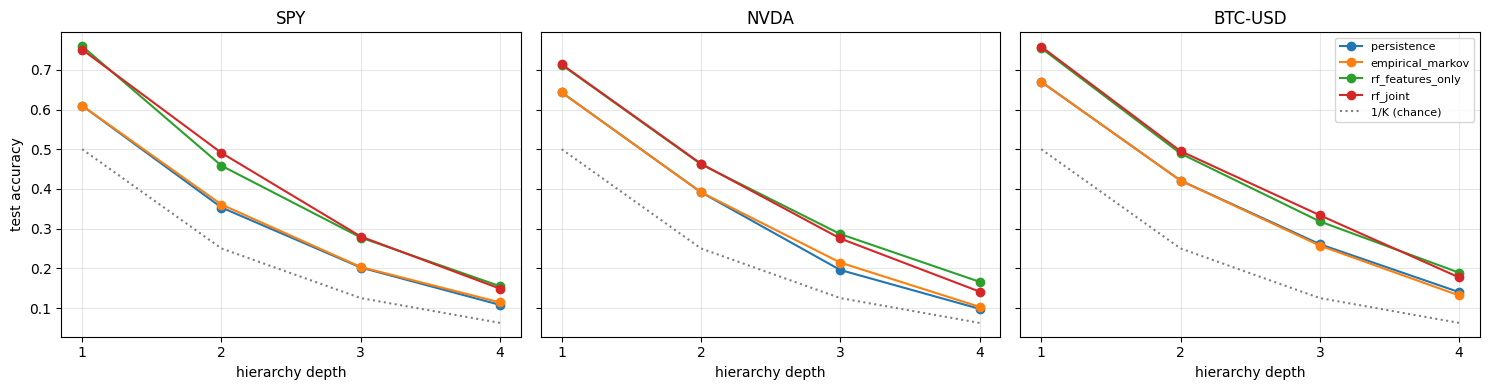

In [6]:
fig, axes = plt.subplots(1, len(TICKERS), figsize=(5 * len(TICKERS), 4), sharey=True)
plot_models = ["persistence", "empirical_markov", "rf_features_only", "rf_joint"]
for ax, tk in zip(axes, TICKERS):
    sub = agg[agg["ticker"] == tk]
    for m in plot_models:
        rows = sub[sub["model"] == m].sort_values("depth")
        ax.plot(rows["depth"], rows["accuracy"], marker="o", label=m)
    chance = sub.drop_duplicates("depth").sort_values("depth")
    ax.plot(chance["depth"], 1.0 / chance["K"], linestyle=":", color="gray", label="1/K (chance)")
    ax.set_title(tk); ax.set_xlabel("hierarchy depth"); ax.set_xticks(DEPTHS)
    if ax is axes[0]: ax.set_ylabel("test accuracy")
    ax.grid(True, alpha=0.3)
axes[-1].legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


## Transition-accuracy view

Persistence is 0 by construction. The empirical Markov kernel argmaxes, so it's also 0 in most rows. The RFs are the only models that can score positively here.


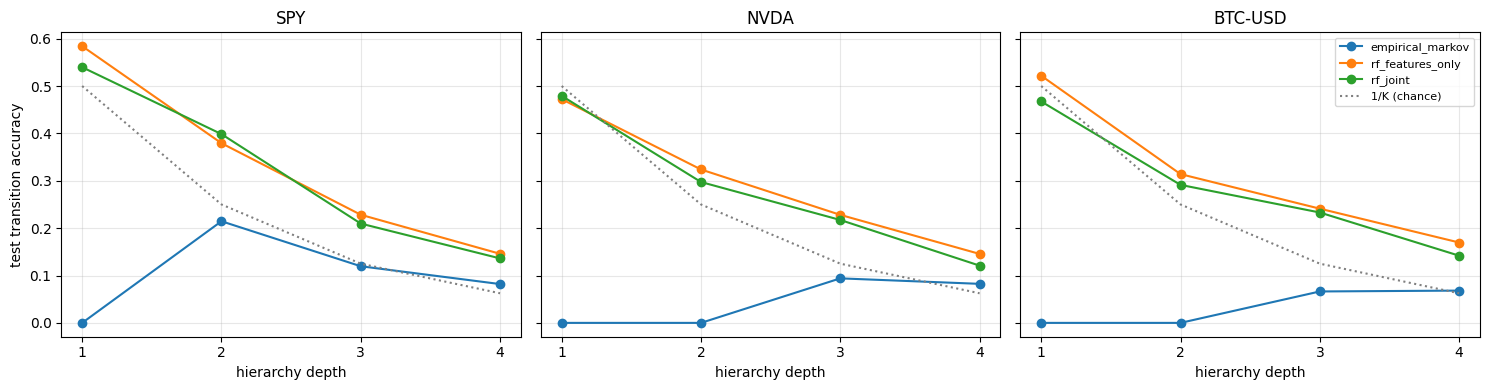

In [7]:
fig, axes = plt.subplots(1, len(TICKERS), figsize=(5 * len(TICKERS), 4), sharey=True)
plot_models = ["empirical_markov", "rf_features_only", "rf_joint"]
for ax, tk in zip(axes, TICKERS):
    sub = agg[agg["ticker"] == tk]
    for m in plot_models:
        rows = sub[sub["model"] == m].sort_values("depth")
        ax.plot(rows["depth"], rows["transition_accuracy"], marker="o", label=m)
    chance = sub.drop_duplicates("depth").sort_values("depth")
    ax.plot(chance["depth"], 1.0 / chance["K"], linestyle=":", color="gray", label="1/K (chance)")
    ax.set_title(tk); ax.set_xlabel("hierarchy depth"); ax.set_xticks(DEPTHS)
    if ax is axes[0]: ax.set_ylabel("test transition accuracy")
    ax.grid(True, alpha=0.3)
axes[-1].legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


## Append to EXPERIMENTS.md


In [8]:
def append_to_journal(agg_df, all_info, journal_path=JOURNAL_PATH):
    header_needed = not os.path.exists(journal_path)
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    config = {
        "notebook": "07_markov_kernel_depth_sweep.ipynb",
        "tickers": TICKERS, "depths": DEPTHS,
        "start_date": START_DATE, "horizon": HORIZON,
        "min_leaf_count": MIN_LEAF_COUNT, "rf_n_estimators": RF_N_ESTIMATORS,
        "rf_grid": RF_GRID, "seed": SEED,
    }
    cols = ["ticker", "depth", "K", "model", "n_test",
            "accuracy", "macro_f1", "transition_count", "transition_accuracy"]
    t = agg_df[cols].copy()
    for c in ("accuracy", "macro_f1", "transition_accuracy"):
        t[c] = t[c].map(lambda v: f"{v:.4f}" if pd.notna(v) else "nan")

    parts = []
    if header_needed:
        parts.append("# Experiments journal\n\nAppend-only log of model-comparison runs.\n")
    parts.append(f"\n---\n")
    parts.append(f"\n## {timestamp} — NB07 Markov-kernel depth sweep (depths={DEPTHS}, horizon={HORIZON})\n")
    parts.append(f"\n**Config**\n\n```json\n{json.dumps(config, indent=2)}\n```\n")
    parts.append(f"\n**Per (ticker, depth, model) test-set results**\n\n")
    parts.append(t.to_markdown(index=False))
    parts.append("\n\n**Accuracy gap vs persistence**\n\n")
    base = agg_df[agg_df["model"] == "persistence"].set_index(["ticker", "depth"])["accuracy"]
    oth = agg_df.set_index(["ticker", "depth", "model"])["accuracy"].unstack("model")
    gap = oth.sub(base, axis=0).round(4)
    parts.append(gap.to_markdown())
    parts.append("\n")
    text = "".join(parts)
    with open(journal_path, "a") as f:
        f.write(text)
    print(f"Appended entry to {journal_path}")
    return text


journal_text = append_to_journal(agg, all_info)


Appended entry to EXPERIMENTS.md


## What to look for

- **Is `rf_joint - persistence` positive at every depth?** If yes, the persistence-beating finding from NB06 is robust to depth. If it collapses at depth=4 (matching NB04's depth), then NB04's classifier failure becomes more understandable.
- **Where does `rf_joint - rf_features_only` peak?** That's the depth at which the soft-membership representation is most useful as additional features.
- **Does persistence accuracy fall as K grows?** It should: finer partitions create more transitions. The question is whether RF accuracy degrades at the same rate, or whether the gap *widens* as K grows (which would say the RF gains more from finer state granularity).
